In [1]:
#!!!!!! THERE IS A MISTAKE IN RUNGE KUTTA FUNCTION !!!!!!

import numpy as np
import copy
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
hbar = 1

In [49]:
def init_sq_th(alpha_: np.float64, theta_: np.float64, mean_n_: np.float64):

    sq_matrix = np.zeros((4,4), dtype=np.float64)
    np.fill_diagonal(sq_matrix, np.cosh(alpha_))

    sq_matrix[0][2], sq_matrix[2][0] = np.sinh(alpha_)*np.cos(theta_), np.sinh(alpha_)*np.cos(theta_)
    sq_matrix[0][3], sq_matrix[3][0] = np.sinh(alpha_)*np.sin(theta_), np.sinh(alpha_)*np.sin(theta_)
    sq_matrix[1][2], sq_matrix[2][1] = np.sinh(alpha_)*np.sin(theta_), np.sinh(alpha_)*np.sin(theta_)
    sq_matrix[1][3], sq_matrix[3][1] = -np.sinh(alpha_)*np.cos(theta_), -np.sinh(alpha_)*np.cos(theta_)
    return (mean_n_ + 1/2)*(sq_matrix @ sq_matrix)

#Changes the input state interacting with the reservoir
def inject_sq_th(cov_M_: np.array, sq_th_M_: np.array):
    cov_M_[:4,4:] = 0
    cov_M_[4:,:4] = 0
    cov_M_[:4,:4] = sq_th_M_

#Initializes the full covariance matrix with included
def init_cov_full():
    cov_full_ = np.zeros((12,12), dtype=np.float64)
    np.fill_diagonal(cov_full_, 1/2)
    return cov_full_

#Initializes the matrix A which contains the information of the Langevian equations
def init_A(gamma_: float, P_: float, W_in_: np.array, J_ij_: np.array, eta_: float):
    A = np.zeros((12,12), dtype=np.float64)
    #First 1-4x1-4 submatrix
    A[0][0], A[1][1], A[2][2], A[3][3] =  -eta_/(2*gamma_), -eta_/(2*gamma_), -eta_/(2*gamma_), -eta_/(2*gamma_)
    #5-12x1-4 submatrix
    A[4][0], A[6][0], A[8][0], A[10][0] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A[5][1], A[7][1], A[9][1], A[11][1] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A[4][2], A[6][2], A[8][2], A[10][2] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    A[5][3], A[7][3], A[9][3], A[11][3] = -W_in_[0], -W_in_[1], -W_in_[2], -W_in_[3]
    #5-12x5-12 submatrix diagonal
    A[4][4], A[6][6], A[8][8], A[10][10] = -gamma_/2, -gamma_/2, -gamma_/2, -gamma_/2
    A[5][5], A[7][7], A[9][9], A[11][11] = -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2, -(gamma_ - P_)/2
    #5-12x5-12 submatrix other values row by row
    A[4][7], A[4][11], A[5][6], A[5][10] = 2*J_ij_[0], -2*J_ij_[3], -2*J_ij_[0], 2*J_ij_[3]
    A[6][5], A[6][9], A[7][4], A[7][8] = 2*J_ij_[0], -2*J_ij_[1], -2*J_ij_[0], 2*J_ij_[1]
    A[8][7], A[8][11], A[9][6], A[9][10] = -2*J_ij_[1], -2*J_ij_[2], 2*J_ij_[1], 2*J_ij_[2]
    A[10][5], A[10][9], A[11][4], A[11][8] = -2*J_ij_[3], -2*J_ij_[2], 2*J_ij_[3], 2*J_ij_[2]

    return A

#Evolves system for one input pair
def time_evolve(cov_M_: np.array, A_: np.array, time_step_: float, tau_: float):
    #Initialize first mode
    first_mode = copy.copy(A_)
    first_mode[:,[2,3]] = 0

    eigenvalues_first_, X1_ = np.linalg.eig(first_mode)
    diagonal_eig1_ = np.diag(eigenvalues_first_)
    lambda1_M_ = np.kron(diagonal_eig1_, np.eye(12)) + np.kron(np.eye(12), diagonal_eig1_)
    Q1_ = np.kron(X1_, X1_)

    #Initialize second mode
    second_mode = copy.copy(A_)
    second_mode[:,[0,1]] = 0

    eigenvalues_second_, X2_ = np.linalg.eig(second_mode)
    diagonal_eig2_ = np.diag(eigenvalues_second_)
    lambda2_M_ = np.kron(diagonal_eig2_, np.eye(12)) + np.kron(np.eye(12), diagonal_eig2_)
    Q2_ = np.kron(X2_, X2_)

    #Vectorize initial state
    v_t_ = cov_M_.flatten('F')

    #First mode interaction
    for i in np.arange(time_step_, tau_+time_step_, time_step_):
        v_t_ = Q1_ @ sp.linalg.expm(lambda1_M_*time_step_) @ np.linalg.inv(Q1_) @ v_t_
        print(np.round(v_t_.reshape((12,12),order='F').real.diagonal(),3))

    #Second mode interaction
    for i in np.arange(tau_+time_step_, 2*tau_+time_step_, time_step_):
        v_t_ = Q2_ @ sp.linalg.expm(lambda2_M_*time_step_) @ np.linalg.inv(Q2_) @ v_t_
        print(np.round(v_t_.reshape((12,12),order='F').real.diagonal(),3))

    #Return the time evolved covariance matrix    
    return v_t_.reshape((12,12),order='F').real

#Calculates the occupation numbers of reservoir sites
def get_occupation_nums(cov_M_: np.array, reservoir_size_: int):
    occupation_numbers_ = np.empty(reservoir_size_, dtype=np.float64)

    for i in range(reservoir_size_):
        occupation_numbers_[i] = 1/2*(cov_M_[4+2*i][4+2*i] + cov_M_[5+2*i][5+2*i] - 1)
    
    return occupation_numbers_
    
#Predicts Y_out
def predict_Y_out(occupation_numbers_: np.array, W_out_: np.array):
    return sum([x*y for x, y in zip(W_out_[0], occupation_numbers_)]), sum([x*y for x, y in zip(W_out_[1], occupation_numbers_)])

#Predicts entanglement of input
def predict_Y_out_entanglement(occupation_numbers_: np.array, W_out_: np.array):
    pred_ = sum([x*y for x, y in zip(W_out_[0], occupation_numbers_)]), sum([x*y for x, y in zip(W_out_[1], occupation_numbers_)])

    if pred_[0] > pred_[1]:
        return 1
    return 0

#Updates the output weights of network
def update_W_out(learning_rate_: np.float64, reg_strength_: np.float64, Y_true_: tuple, Y_pred_: tuple, occupation_numbers_: np.array, W_out_: np.array, reservoir_size_: int):

    for i in range(reservoir_size_):
        W_out_[i][0] += learning_rate_*(occupation_numbers_[i]*(Y_true_[0]-Y_pred_[0]) - reg_strength_*W_out_[i][0])
        W_out_[i][1] += learning_rate_*(occupation_numbers_[i]*(Y_true_[1]-Y_pred_[1]) - reg_strength_*W_out_[i][1])
    
#Calculates negativity of input state
def negativity(cov_sq_th_: np.array):
    det_V_ = np.linalg.det(cov_sq_th_)
    det_A_ = np.linalg.det(cov_sq_th_[:2,:2])  
    det_B_ = np.linalg.det(cov_sq_th_[2:,2:])
    det_C_ = np.linalg.det(cov_sq_th_[:2,2:])
    sigma_ = det_A_ + det_B_ - 2*det_C_
    return -np.log(np.sqrt(2)*(np.sqrt(sigma_ - np.sqrt(sigma_**2 - 4*det_V_))))

#Reveals true entanglement of input
def assign_entanglement(negativity_: np.float64):
    if negativity_ <= 0:
        return (0,1)
    return (1,0)
    


In [50]:
#Initialize variables
number_of_inputs = 200
reservoir_size = 4

np.random.seed(20)
theta = np.random.uniform(0,2*np.pi,(number_of_inputs,))
s = np.random.uniform(0.8,0.95,(number_of_inputs,))
phi = np.random.uniform(0.5-np.pi/10, 0.5+np.pi/10, (number_of_inputs,))
abs_alpha = np.array([x*np.sin(y) for x, y in zip(s,phi)])
mean_n = np.array([x*x*np.cos(y)*np.cos(y) for x, y in zip(s,phi)])

#Initialize covariance matrices for input states
input_states_train = []
for i in range(number_of_inputs):
    input_states_train.append(init_sq_th(abs_alpha[i], theta[i], mean_n[i]))

Y_out_true = np.empty(number_of_inputs, dtype=tuple)
for idx, input in enumerate(input_states_train):
    Y_out_true[idx] = assign_entanglement(negativity(input))

gamma = 0.1
P = 0.1*gamma

tau = hbar/gamma
time_step = tau / 4

W_in = np.random.uniform(0, gamma, (4,))
J_ij = np.random.uniform(-gamma, gamma, (4,))
eta = np.sum(W_in**2)

learning_rate = 0.1
regularization_strength = 0.05



In [52]:
#Initialize covariance matrix of system
cov_full = init_cov_full()
matrix_A = init_A(gamma, P, W_in, J_ij, eta)

W_out = np.random.uniform(0,1,(reservoir_size,2))
Y_out_pred = np.empty(number_of_inputs, dtype=tuple)
for idx, input in enumerate(input_states_train):
    inject_sq_th(cov_full, input)
    print(idx)
    cov_full = time_evolve(cov_full, matrix_A, time_step, tau)
    occupation_nums_ = get_occupation_nums(cov_full, reservoir_size)
    Y_true_ = Y_out_true[idx]
    #print(np.round(cov_full.diagonal(),3))
    #print(Y_true_)
    #print(predict_Y_out(occupation_nums_, W_out))
    Y_pred_ = Y_out_pred[idx] = predict_Y_out(occupation_nums_, W_out)
    update_W_out(learning_rate, regularization_strength, Y_true_, Y_pred_, occupation_nums_, W_out, reservoir_size)
    #print(occupation_nums_)
    #print(W_out)
    print("")
    

0
[0.927 0.927 1.504 1.504 0.392 0.4   0.43  0.439 0.411 0.42  0.453 0.462]
[0.571 0.571 1.504 1.504 0.315 0.321 0.424 0.435 0.367 0.378 0.467 0.478]
[0.352 0.352 1.504 1.504 0.264 0.267 0.436 0.45  0.341 0.351 0.456 0.469]
[0.217 0.217 1.504 1.504 0.234 0.24  0.437 0.457 0.32  0.33  0.405 0.422]
[0.217 0.217 0.927 0.927 0.216 0.229 0.282 0.506 0.324 0.275 0.272 0.406]
[0.217 0.217 0.571 0.571 0.22  0.216 0.252 0.518 0.377 0.211 0.293 0.4  ]
[0.217 0.217 0.352 0.352 0.247 0.185 0.296 0.48  0.421 0.168 0.314 0.383]
[0.217 0.217 0.217 0.217 0.286 0.14  0.364 0.406 0.445 0.145 0.3   0.337]

1
[0.941 0.941 1.526 1.526 0.306 0.103 0.366 0.293 0.436 0.139 0.264 0.255]
[0.58  0.58  1.526 1.526 0.297 0.096 0.377 0.273 0.431 0.163 0.299 0.267]
[0.357 0.357 1.526 1.526 0.267 0.112 0.375 0.3   0.417 0.191 0.319 0.282]
[0.22  0.22  1.526 1.526 0.237 0.135 0.359 0.33  0.394 0.214 0.301 0.268]
[0.22  0.22  0.941 0.941 0.228 0.134 0.41  0.185 0.409 0.171 0.373 0.096]
[0.22  0.22  0.58  0.58  0.23  0.

In [ ]:
for i in range(number_of_inputs):
    print(f"True: {Y_out_true[i]}, Pred: ({np.round(Y_out_pred[i][0],2)},{np.round(Y_out_pred[i][1],2)})")


True: (1, 0), Pred: (-0.26,-0.11)
True: (1, 0), Pred: (-0.3,-0.15)
True: (1, 0), Pred: (-0.29,-0.14)
True: (1, 0), Pred: (-0.24,-0.1)
True: (1, 0), Pred: (-0.28,-0.15)
True: (1, 0), Pred: (-0.25,-0.13)
True: (1, 0), Pred: (-0.23,-0.11)
True: (1, 0), Pred: (-0.16,-0.05)
True: (0, 1), Pred: (-0.22,-0.12)
True: (0, 1), Pred: (-0.19,-0.1)
True: (1, 0), Pred: (-0.16,-0.07)
True: (1, 0), Pred: (-0.14,-0.06)
True: (0, 1), Pred: (-0.14,-0.07)
True: (1, 0), Pred: (-0.12,-0.05)
True: (1, 0), Pred: (-0.13,-0.08)
True: (0, 1), Pred: (-0.11,-0.05)
True: (1, 0), Pred: (-0.08,-0.02)
True: (0, 1), Pred: (-0.1,-0.06)
True: (1, 0), Pred: (-0.07,-0.02)
True: (0, 1), Pred: (-0.08,-0.05)
True: (1, 0), Pred: (-0.06,-0.04)
True: (1, 0), Pred: (-0.05,-0.02)
True: (1, 0), Pred: (-0.03,0.0)
True: (1, 0), Pred: (-0.02,0.0)
True: (0, 1), Pred: (-0.01,-0.01)
True: (0, 1), Pred: (-0.02,-0.02)
True: (1, 0), Pred: (-0.01,-0.01)
True: (1, 0), Pred: (0.01,0.01)
True: (1, 0), Pred: (0.02,0.0)
True: (1, 0), Pred: (0.03,0

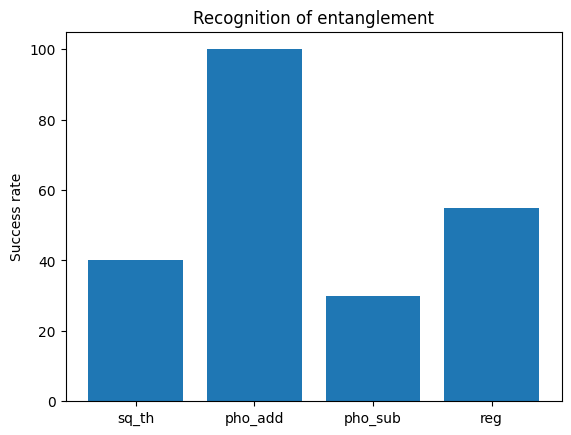

In [7]:
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [48]:
print(np.round(matrix_A,2))

[[-0.1   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.   -0.1   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.1   0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.   -0.1   0.    0.    0.    0.    0.    0.    0.    0.  ]
 [-0.01  0.   -0.01  0.   -0.05  0.    0.   -0.19  0.    0.    0.    0.14]
 [ 0.   -0.01  0.   -0.01  0.   -0.04  0.19  0.    0.    0.   -0.14  0.  ]
 [-0.08  0.   -0.08  0.    0.   -0.19 -0.05  0.    0.    0.08  0.    0.  ]
 [ 0.   -0.08  0.   -0.08  0.19  0.    0.   -0.04 -0.08  0.    0.    0.  ]
 [-0.06  0.   -0.06  0.    0.    0.    0.    0.08 -0.05  0.    0.   -0.18]
 [ 0.   -0.06  0.   -0.06  0.    0.   -0.08  0.    0.   -0.04  0.18  0.  ]
 [-0.1   0.   -0.1   0.    0.    0.14  0.    0.    0.   -0.18 -0.05  0.  ]
 [ 0.   -0.1   0.   -0.1  -0.14  0.    0.    0.    0.18  0.    0.   -0.04]]
